First 5 rows of the dataset:


,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,3,16884.92400
1,18,0,33.770,1,0,2,1725.55230
2,28,0,33.000,3,0,2,4449.46200
3,33,0,22.705,0,0,1,21984.47061
4,32,0,28.880,0,0,1,3866.85520


Shape of dataset:
(1338, 7)

Number of rows: 1338
Number of columns: 7

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   int64  
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   int64  
 5   region    1338 non-null   int64  
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(5)
memory usage: 73.3 KB

Data Types:
age           int64
sex           int64
bmi         float64
children      int64
smoker        int64
region        int64
charges     float64
dtype: object

Statistical Summary:


,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,0.494768,30.663397,1.094918,0.204783,1.515695,13270.422265
std,14.049960,0.500160,6.098187,1.205493,0.403694,1.104885,12110.011237
min,18.000000,0.000000,15.960000,0.000000,0.000000,0.000000,1121.873900
25%,27.000000,0.000000,26.296250,0.000000,0.000000,1.000000,4740.287150
50%,39.000000,0.000000,30.400000,1.000000,0.000000,2.000000,9382.033000
75%,51.000000,1.000000,34.693750,2.000000,0.000000,2.000000,16639.912515
max,64.000000,1.000000,53.130000,5.000000,1.000000,3.000000,63770.428010



Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
Independent Variable: BMI
Dependent Variable: Charges

Why BMI?

BMI is selected because it is a numerical variable and has a
meaningful relationship with medical/insurance expenses.
It is also suitable for demonstrating Simple Linear Regression
because we use only one independent variable.


========== MULTIPLE LINEAR REGRESSION ==========
MAE: 4186.508898366434
R2 Score: 0.7833463107364539


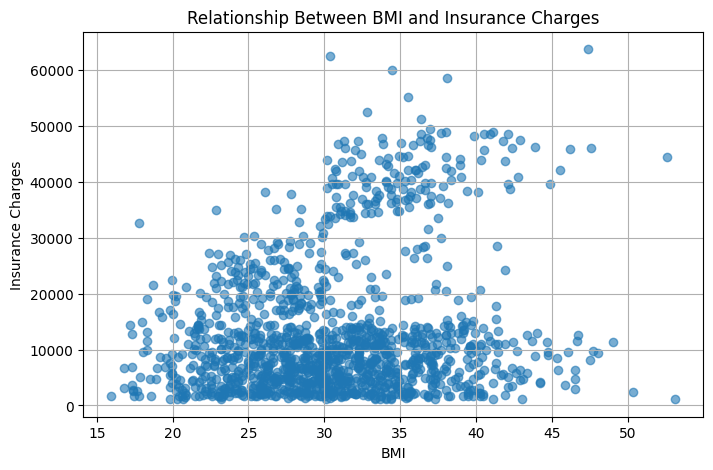

Training data size: (1070, 1)
Testing data size: (268, 1)

========== SIMPLE LINEAR REGRESSION ==========
Intercept: 1353.0730722046683
Slope: 392.43654416987977
Charges = 1353.07 + (392.44 × BMI)

========== MODEL EVALUATION ==========
Mean Absolute Error (MAE): 9784.65259627133
R-squared (R2) Score: 0.03970193117941878


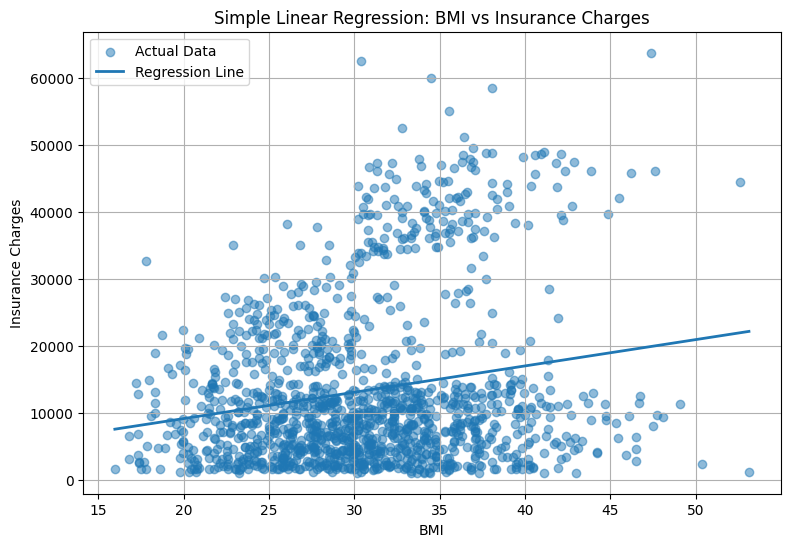

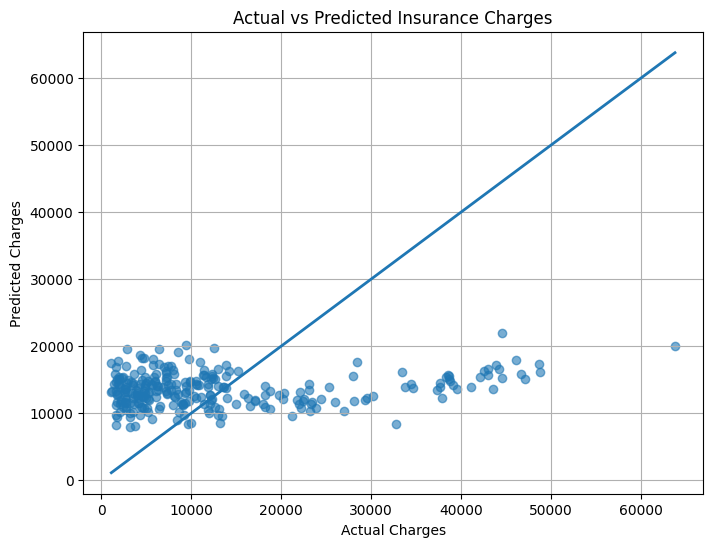


========== PREDICTIONS FOR NEW DATA ==========


,BMI,Predicted Charges
0,20,9201.803956
1,25,11163.986676
2,30,13126.169397
3,35,15088.352118
4,40,17050.534839



========== INTERPRETATION ==========

1. Regression Coefficient / Slope:
   The slope is 392.44.
   For every one-unit increase in BMI, the predicted insurance
   charge changes by approximately $392.44, on average.

2. Intercept:
   The intercept is 1353.07.

3. Mean Absolute Error (MAE):
   The MAE is 9784.65.
   A lower MAE indicates better prediction accuracy.

4. R-squared (R2):
   The R2 score is 0.0397.
   It indicates how much variation in insurance charges is
   explained by BMI.

5. Simple vs Multiple Linear Regression:

   Simple Linear Regression R2: 0.0397
   Multiple Linear Regression R2: 0.7833

   Multiple Linear Regression uses additional variables such as
   age, children, sex, smoker, and region.


========== MODEL COMPARISON ==========


,Model,MAE,R2 Score
0,Simple Linear Regression,9784.652596,0.039702
1,Multiple Linear Regression,4186.508898,0.783346


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

%matplotlib inline

df = pd.read_csv("insurance_Dataset_for_LabTask.csv")

print("First 5 rows of the dataset:")
display(df.head())

print("Shape of dataset:")
print(df.shape)

print("\nNumber of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nDataset Information:")
df.info()

print("\nData Types:")
print(df.dtypes)

print("\nStatistical Summary:")
display(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

X = df[['bmi']]
y = df['charges']

print("Independent Variable: BMI")
print("Dependent Variable: Charges")

print("\nWhy BMI?")
print("""
BMI is selected because it is a numerical variable and has a
meaningful relationship with medical/insurance expenses.
It is also suitable for demonstrating Simple Linear Regression
because we use only one independent variable.
""")

X_multiple = pd.get_dummies(
    df[['age', 'bmi', 'children', 'sex', 'smoker', 'region']],
    drop_first=True
)

y_multiple = df['charges']

X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multiple,
    y_multiple,
    test_size=0.20,
    random_state=42
)

multiple_model = LinearRegression()
multiple_model.fit(X_train_multi, y_train_multi)

y_pred_multi = multiple_model.predict(X_test_multi)

mae_multi = mean_absolute_error(y_test_multi, y_pred_multi)
r2_multi = r2_score(y_test_multi, y_pred_multi)

print("\n========== MULTIPLE LINEAR REGRESSION ==========")
print("MAE:", mae_multi)
print("R2 Score:", r2_multi)

plt.figure(figsize=(8, 5))
plt.scatter(df['bmi'], df['charges'], alpha=0.6)
plt.xlabel("BMI")
plt.ylabel("Insurance Charges")
plt.title("Relationship Between BMI and Insurance Charges")
plt.grid(True)
plt.show()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

simple_model = LinearRegression()
simple_model.fit(X_train, y_train)

intercept = simple_model.intercept_
slope = simple_model.coef_[0]

print("\n========== SIMPLE LINEAR REGRESSION ==========")
print("Intercept:", intercept)
print("Slope:", slope)

print(f"Charges = {intercept:.2f} + ({slope:.2f} × BMI)")

y_pred = simple_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n========== MODEL EVALUATION ==========")
print("Mean Absolute Error (MAE):", mae)
print("R-squared (R2) Score:", r2)

y_line = simple_model.predict(X)

plt.figure(figsize=(9, 6))

plt.scatter(
    df['bmi'],
    df['charges'],
    alpha=0.5,
    label="Actual Data"
)

sorted_indices = np.argsort(df['bmi'].values)

plt.plot(
    df['bmi'].values[sorted_indices],
    y_line[sorted_indices],
    linewidth=2,
    label="Regression Line"
)

plt.xlabel("BMI")
plt.ylabel("Insurance Charges")
plt.title("Simple Linear Regression: BMI vs Insurance Charges")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linewidth=2
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")
plt.grid(True)
plt.show()

new_bmi = pd.DataFrame({
    'bmi': [20, 25, 30, 35, 40]
})

new_predictions = simple_model.predict(new_bmi)

prediction_results = pd.DataFrame({
    'BMI': new_bmi['bmi'],
    'Predicted Charges': new_predictions
})

print("\n========== PREDICTIONS FOR NEW DATA ==========")
display(prediction_results)

print("\n========== INTERPRETATION ==========")

print(f"""
1. Regression Coefficient / Slope:
   The slope is {slope:.2f}.
   For every one-unit increase in BMI, the predicted insurance
   charge changes by approximately ${abs(slope):.2f}, on average.

2. Intercept:
   The intercept is {intercept:.2f}.

3. Mean Absolute Error (MAE):
   The MAE is {mae:.2f}.
   A lower MAE indicates better prediction accuracy.

4. R-squared (R2):
   The R2 score is {r2:.4f}.
   It indicates how much variation in insurance charges is
   explained by BMI.

5. Simple vs Multiple Linear Regression:

   Simple Linear Regression R2: {r2:.4f}
   Multiple Linear Regression R2: {r2_multi:.4f}

   Multiple Linear Regression uses additional variables such as
   age, children, sex, smoker, and region.
""")

comparison = pd.DataFrame({
    'Model': [
        'Simple Linear Regression',
        'Multiple Linear Regression'
    ],
    'MAE': [
        mae,
        mae_multi
    ],
    'R2 Score': [
        r2,
        r2_multi
    ]
})

print("\n========== MODEL COMPARISON ==========")
display(comparison)
